In [1]:
# import default modules
import numpy as np
from scipy import interpolate
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d, Axes3D 
from matplotlib import cm
import sys
import os
from scipy.ndimage import gaussian_filter1d

# method to import xbtools with try routine
try:
    import xbTools
except ImportError:
    print('**no xbTools installation found in environment, adding parent path of notebook to see if it works')
    sys.path.append(os.path.abspath(os.path.join('..', '..', 'xbeach-toolbox')))

In [2]:
# import specific tools from xbTools
# sys.path.append(os.path.abspath(os.path.join('..' )))
# from xbTools.grid.creation import xgrid, ygrid
# from xbTools.grid.extension import seaward_extend, lateral_extend
# from xbTools.xbeachtools import XBeachModelSetup
# from xbTools.general import wave_functions, visualize_meshL2_width_above

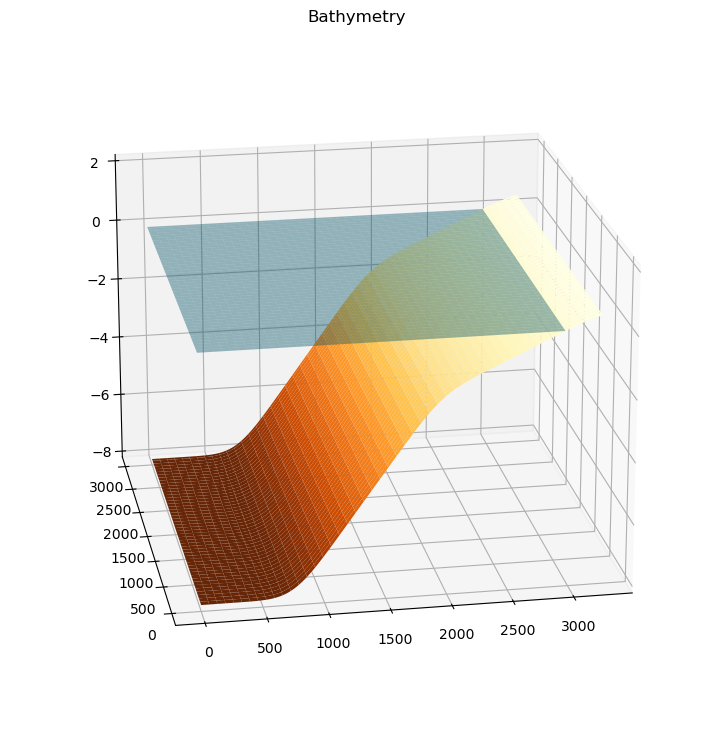

Shoreface starts at X = 750.0m
Transition to Slope 2 at X = 1944.54m
Shoreline (Z=0) at approx X = 2944.54m


In [8]:
# generate bathymetry
z0 = 8.0                      # initial depth (m)
theta_1 = .3                  # slope 1 (degrees)
theta_2 = .1                  # slope 2 (degrees)
x_flat_len = 750.0            # flat area before shore face (m)
dx = 3.0                      # grid spacing (m)
length_y = 3000.0             # beach/domain length (m) 
sigma_smooth = 50             # smoothing factor
w_szone = 1000.0              # surfzone width (m)
w_beach = 300.0               # beach width (m)

tan1 = np.tan(np.deg2rad(theta_1))
tan2 = np.tan(np.deg2rad(theta_2))
z_trans_elevation = -(w_szone * tan2)
L1_width = (z_trans_elevation - (-z0)) / tan1
x_total = x_flat_len + L1_width + w_szone + w_beach
x_final = np.arange(0, x_total + dx, dx)
y_final = np.arange(0, length_y + dx, dx)

def calculate_elevation(x_val):
    xr = x_val - x_flat_len
    if xr < 0:
        return -z0
    elif 0 <= xr < L1_width:
        return tan1 * xr - z0
    else:
        z_at_end_l1 = tan1 * L1_width - z0
        return z_at_end_l1 + tan2 * (xr - L1_width)

f_x = np.array([calculate_elevation(x) for x in x_final])
elevation_1d = gaussian_filter1d(f_x, sigma=sigma_smooth, mode='nearest')

X, Y = np.meshgrid(x_final, y_final)
elevation_2d = np.tile(elevation_1d, (len(y_final), 1))
bathy_2d = -elevation_2d

# plotting
water_mask = np.ma.masked_where(elevation_2d > 0, np.zeros_like(elevation_2d))
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, elevation_2d, cmap='YlOrBr_r', edgecolor='none', alpha=1)
water = ax.plot_surface(X, Y, water_mask, color='#006884', alpha=0.4, linewidth=0)
ax.set_title(f'Bathymetry')
ax.set_zlim(np.min(elevation_2d), 2.0)
ax.view_init(elev=20, azim=-100)
plt.show()

np.savetxt('bathy.dep', bathy_2d, fmt='%.4f')
np.savetxt('x.grd', X, fmt='%.4f')
np.savetxt('y.grd', Y, fmt='%.4f')

print(f"Shoreface starts at X = {x_flat_len}m")
print(f"Transition to Slope 2 at X = {x_flat_len + L1_width:.2f}m")
print(f"Shoreline (Z=0) at approx X = {x_flat_len + L1_width + w_szone:.2f}m")

In [6]:
wave_input = """
Hm0 = 0.8
Tp = 15.0
mainang = 300.0
gammajsp = 20.0
s = 16.0
fnyq = 0.3
eps = 0.01         
dryslp = 1.0       
"""

with open("jonswap.txt", "w") as f:
    f.write(wave_input)

In [7]:
nx = X.shape[1] - 1
ny = X.shape[0] - 1

params = f"""
! --- Grid Parameters ---
nx           = {nx}
ny           = {ny}
coord        = cartesian    
vardx        = 1            
xfile        = x.grd
yfile        = y.grd
depfile      = bathy.dep
posdwn       = 1    
posfree      = 1 
split        = 1
outputformat = netcdf

! --- Wave & Boundary Conditions ---
nonh         = 1
wavemodel    = nonh
dirnorm      = 0
thetamin     = -90          
thetamax     = 90           
dtheta       = 10           
instat       = jons        
bcfile       = jonswap.txt  
front        = nonh_1d     
back         = wall       
left         = neumann    
right        = neumann
reuse        = 0
CFL          = 0.5 
nhq3d        = 1

! --- Sediment Parameters (Uniform) ---
morphology   = 1
sedtrans     = 1
ngd          = 1            
D50          = 0.0002       
D90          = 0.0003
por          = 0.4
rhos         = 2650.0     

! --- Model Time ---
tstart       = 0 
tstop        = 3600                            
tintm        = 600          
tintg        = 2           

nglobalvar   = 12           
zs
zb
H
ue
ve
Subg
Susg
Svbg
Svsg
dzsdx
dzsdy
sedero
"""

with open("params.txt", "w") as f:
    f.write(params)

In [6]:
### run in terminal
### module load MPICH/3.2.1
### mpirun -n <number_of_cores> xbeach